# Projeto Sprint 6 - Loja Online Ice


In [1]:
#Carregando as bibliotecas
import pandas as pd 
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
from scipy import stats as st
import math as m

In [2]:
#importando o arquivo
games = pd.read_csv('/datasets/games.csv')

## Preparação dos Dados

In [3]:
#Analísando as informações para ver há valores nulos/ausentes, os tipos dos dtypes (se condiz com os dados de cada coluna).
games.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
#Para poder ter uma visão melhor de como os dados estão distribuídos.
games.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [5]:
#Ciclo for para percorrer e transforma todas as palavras das colunas em minúsculas.
new_columns_name = []
for old_name in games.columns:
    name_lowered = old_name.lower()
    new_columns_name.append(name_lowered)
games.columns = new_columns_name    

In [6]:
#Facilitando a forma de observar a quantidades de valores nulo/ausentes e a entender melhor o que fazer com cada um deles. 
games.isnull().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

In [7]:
#Observando se todas as colunas em que name está nulo estavam preenchidas e, pudemos ver que os valores nulos de Genre também estão aqui tambem.
games[games['name'].isnull()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


In [8]:
#Removendo os valores nulos de Name e Genre.
games = games.dropna(subset=['name'])

In [9]:
#Criando uma coluna com valores Nan substituídos por zero para analíse da projeção para 2017, e mantendo coluna original para não eliminar outros dados relevantes..
games['year_new'] = games['year_of_release'].fillna(0)

#Passando a nova coluna year_new para 'int'.
games['year_new'] = games['year_new'].astype(int)

Optei por excluir as linhas names e genre estão nulas em varias colunas e tem uma porcentagem insignificante de vendas, visto que se trata apenas de 2 linhas e não vai interferir nas analíses futura. Criei uma outra coluna (year_new) e nessa coluna substituíndo os valores nan por 0, mantendo a coluna original de year para melhor analíse dos dados agora e futuras. Não converti a coluna user_score que esta como object para int porque tem 2424 colunas que estão como tbd(s ser determinado) e achei válido manter para as análises futuras.

In [10]:
#Observando se há valores duplicados.
games.duplicated().sum()

0

In [11]:
#Criando coluna 'total_vendas'. 
games['total_vendas'] = games[['na_sales','eu_sales','jp_sales','other_sales']].sum(axis=1)

## Analisando os Dados

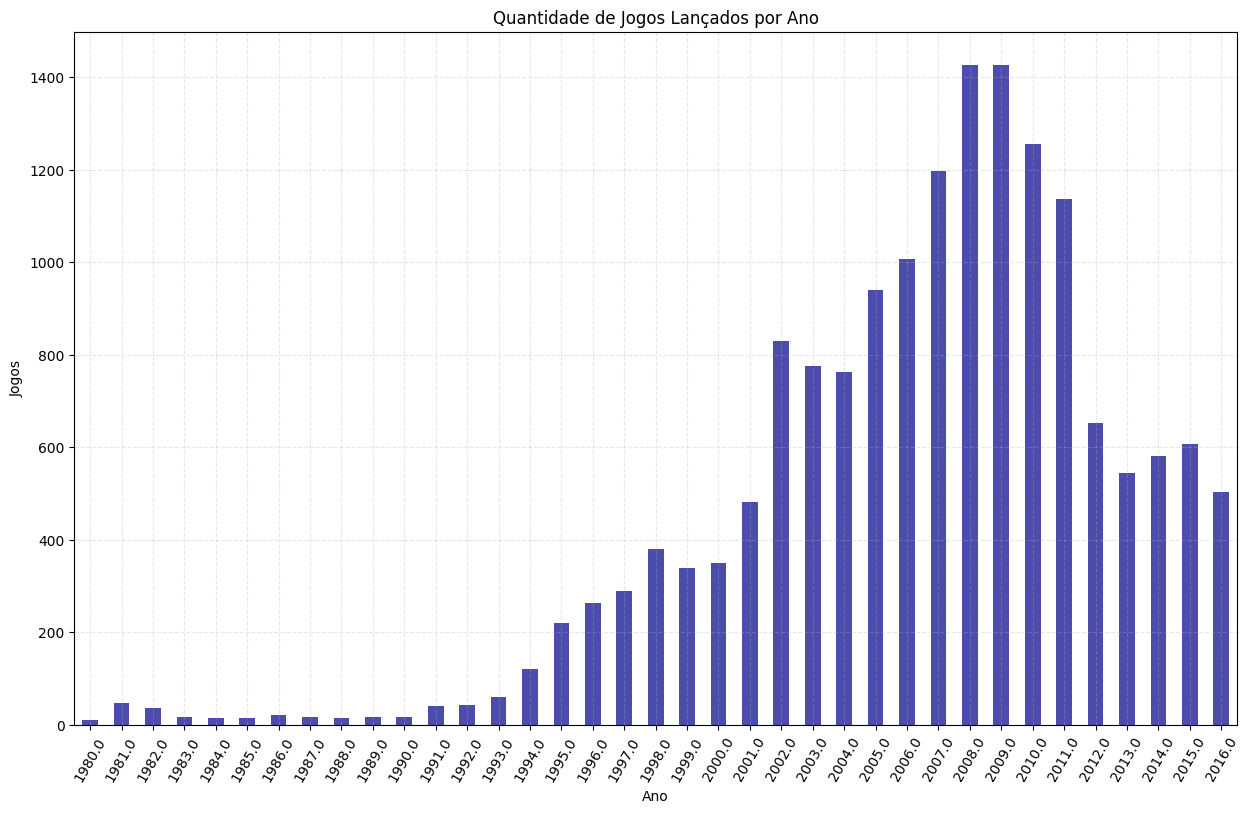

In [12]:
#Calculando quantos jogos foram lançados por ano.
new_games_years = games['year_of_release'].value_counts().sort_index()

#Gráfico para ilustrar.
ax = new_games_years.plot(kind='bar', figsize=(15,9),
                         color='darkblue',
                         alpha=0.7)
ax.set_xlabel('Ano')
ax.set_ylabel('Jogos')
ax.set_title('Quantidade de Jogos Lançados por Ano')
ax.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=60)
plt.show()

O Gráfico ilustra a quantidades que foram lançados durante os anos. Podemos ver que entre 2007 e 2008 atingimos uma número superior a 1400 jogos por ano. Agora vamos tentar entender quer lucrou com tudo isso ou parte disso. 

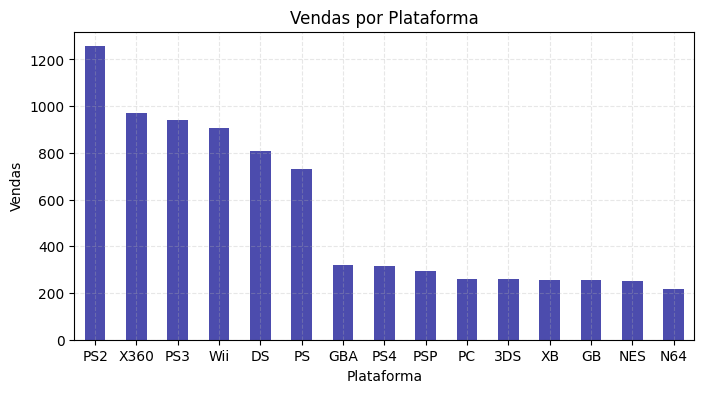

In [13]:
#Observando como as vendas variam de plataforma para plataforma e selecionando o top 15 de vendas para ilustrar em gráfico.
vendas_por_platform = games.groupby('platform')['total_vendas'].sum().sort_values(ascending=False)
top_15_platform = vendas_por_platform.head(15)

#Gráfico para ilustrar.
ax = top_15_platform.plot(kind='bar', figsize=(8,4),
                         alpha=0.7, color='darkblue')
ax.set_xlabel('Plataforma')
ax.set_ylabel('Vendas')
ax.set_title('Vendas por Plataforma')
ax.grid(True, alpha=0.3, linestyle= '--')
plt.xticks(rotation=0)
plt.show()

O Gráfico ilustra as 15 plataformas que tiveram maior números de vendas ate 2016. E podemos ver o líder de vendas (PS2) seguido de 3 grandes plataformas (X360, PS3, Wii).

In [14]:
#Criando uma tabela com os valores de vendas das plataforma e o ano. 
vendas_plataforma_ano = pd.pivot_table(games,values='total_vendas',columns='year_of_release',index='platform', aggfunc='sum').sort_index(ascending=False)

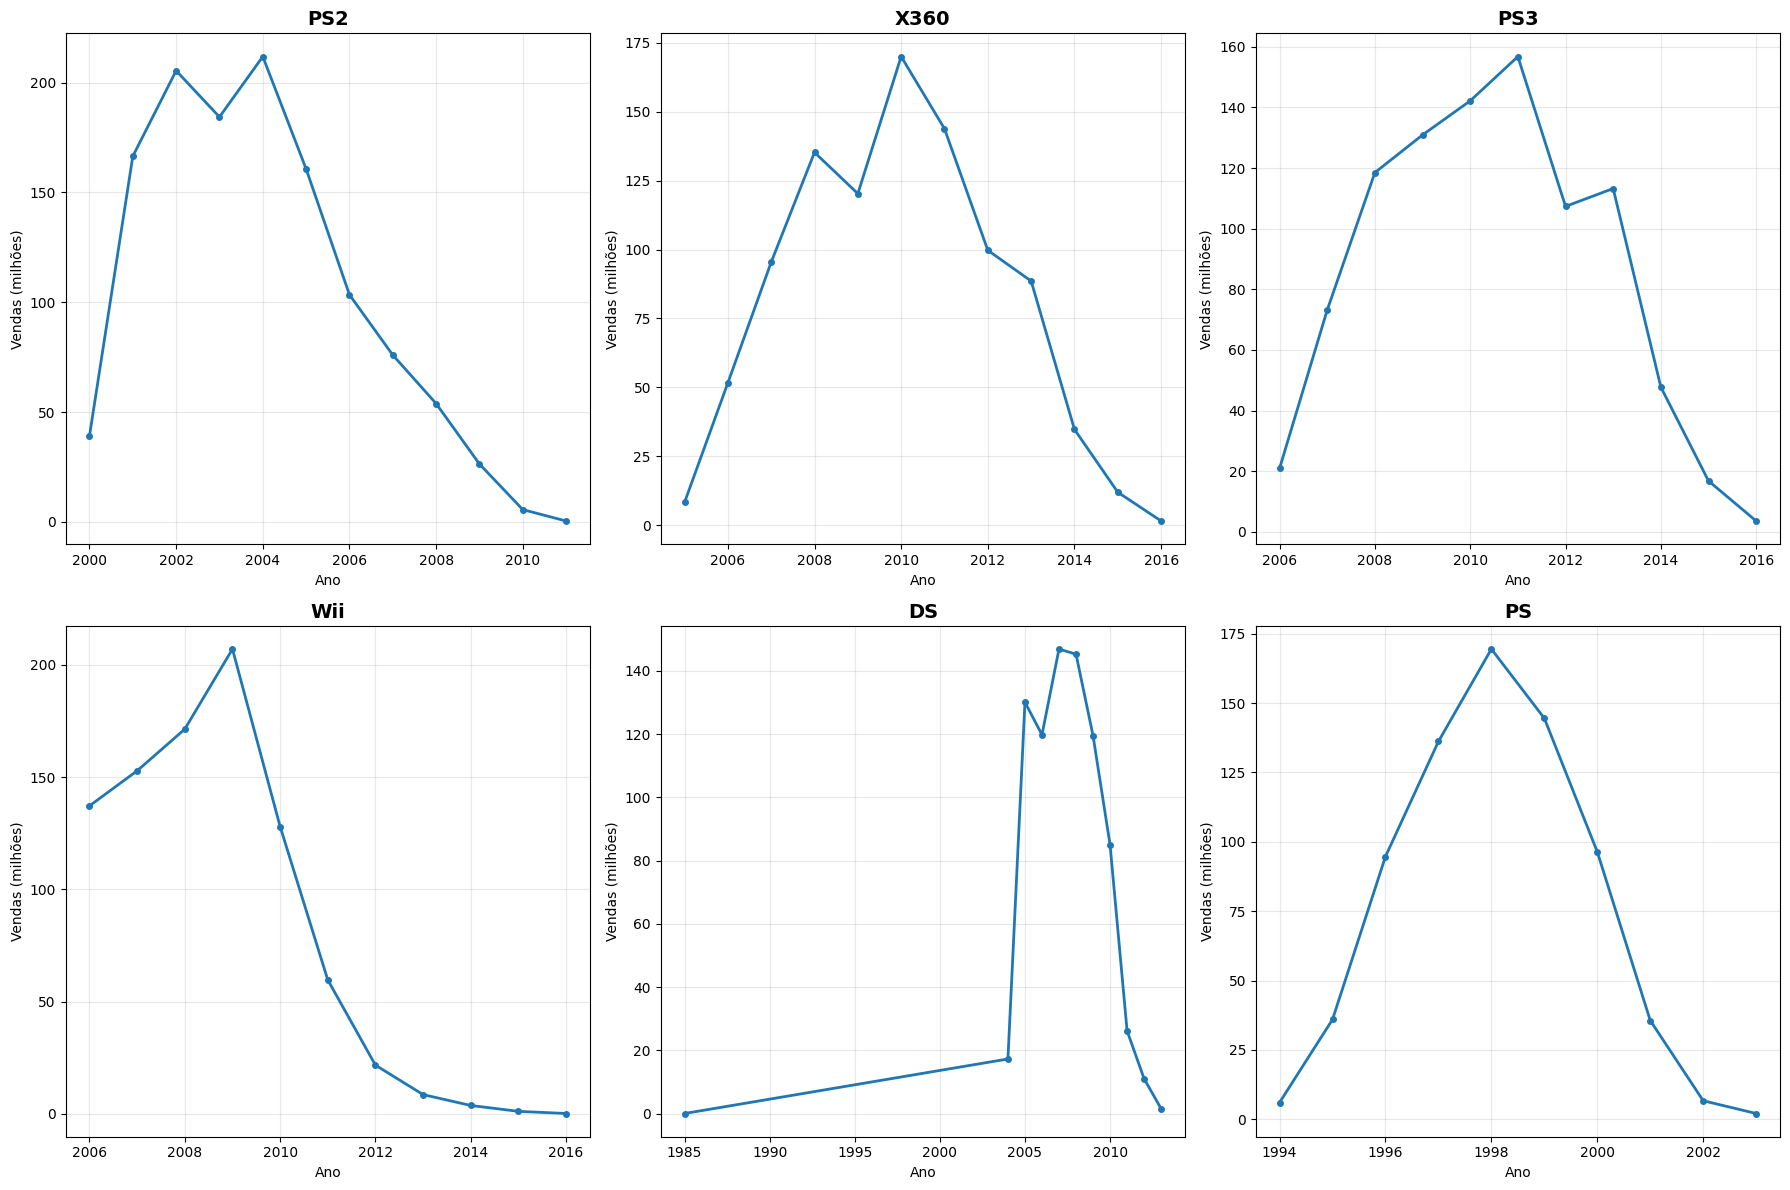

In [15]:
#Filtrando o top15 valor de vendas das plataforma por ano. 
top15_vendas_por_ano = vendas_plataforma_ano.loc[top_15_platform.index]

#Cria subplot para as 6 principais plataformas.
top_6_plataforma = top_15_platform.head(6)

#Grafíco ilustrando.
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, platform in enumerate(top_6_plataforma.index):
    # Dados de cada plataforma específica
    platform_data = top15_vendas_por_ano.loc[platform].dropna()
    
    axes[i].plot(platform_data.index, platform_data.values, 
                marker='o', linewidth=2, markersize=4)
    axes[i].set_title(f'{platform}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Ano')
    axes[i].set_ylabel('Vendas (milhões)')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

O Gráficos ilustram o ano do surgimento das top6 plataformas e suas vendas ao longo da sua vida 'utíl'.Podemos notar que quando PS começa a cair o PS2 assume as vendas no seu lugar e quando ele começa cair em seguida vem o PS3 subindo em vendas, a evolução da linha PlayStation mostra reinvenção constante, mantendo liderança. O Wii teve um pico muito bom em 2009/2010 e despencou. O X360 deve um pico bom em dendas durante 4/5 anos (de 2007 a 2012) e despencou.

In [16]:
#Encontrando o primeiro e último ano de cada plataforma.
ciclo_vida_plataforma = games.groupby('platform')['year_of_release'].agg(['min','max','count'])
ciclo_vida_plataforma.columns = ['primeiro_ano','ultimo_ano','total_jogos']

# Calculando a duração do ciclo de vida de cada plataforma.
ciclo_vida_plataforma['duracao_anos'] = ciclo_vida_plataforma['ultimo_ano'] - ciclo_vida_plataforma['primeiro_ano']

# Colocando em ordem crescente os anos 
ciclo_vida_plataforma = ciclo_vida_plataforma.sort_values('primeiro_ano')

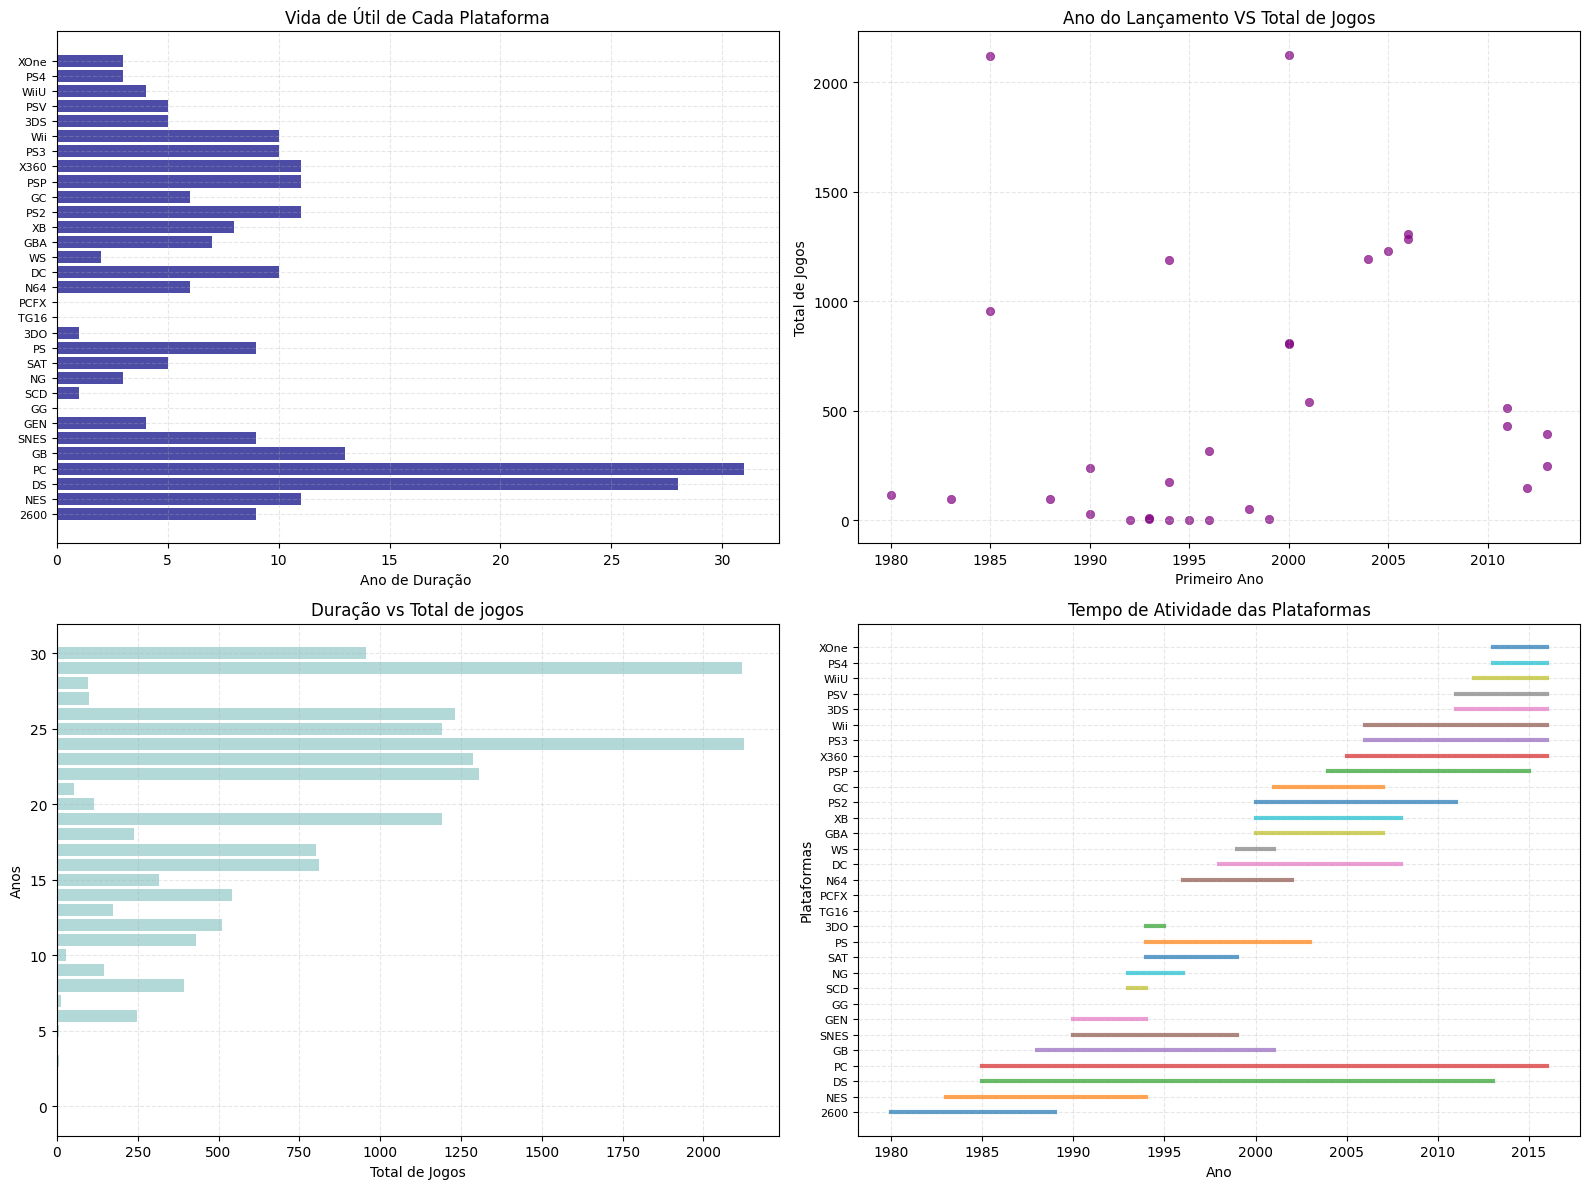

In [17]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

## 1. Cronologia das plataformas.
axes[0,0].barh(range(len(ciclo_vida_plataforma)),
               ciclo_vida_plataforma['duracao_anos'],
               color='Navy', 
               alpha=0.7)
axes[0,0].set_yticks(range(len(ciclo_vida_plataforma)))
axes[0,0].set_yticklabels(ciclo_vida_plataforma.index, fontsize=8)
axes[0,0].set_title('Vida de Útil de Cada Plataforma')
axes[0,0].set_xlabel('Ano de Duração ')
axes[0,0].grid(True, alpha=0.3, linestyle='--')


# 2. Relação: Ano de lançamento vs Total de jogos
axes[0,1].scatter(ciclo_vida_plataforma['primeiro_ano'],
               ciclo_vida_plataforma['total_jogos'], 
               alpha=0.7,
               color='purple',
              linewidth=0.5)
axes[0,1].set_title('Ano do Lançamento VS Total de Jogos')
axes[0,1].set_xlabel('Primeiro Ano')
axes[0,1].set_ylabel('Total de Jogos')
axes[0,1].grid(True, alpha=0.3, linestyle='--')

# 3. Duração vs Total de jogos

dados_ordenados = ciclo_vida_plataforma.sort_values('duracao_anos')
axes[1,0].barh(range(len(dados_ordenados)), 
               dados_ordenados['total_jogos'],
               height=0.8, 
               alpha=0.3, 
               color='teal')
axes[1,0].set_title('Duração vs Total de jogos')
axes[1,0].set_xlabel('Total de Jogos')
axes[1,0].set_ylabel('Anos')
axes[1,0].grid(True, alpha=0.3, linestyle='--')


#4. Timeline visual das gerações
for i, platform in enumerate (ciclo_vida_plataforma.index):
    inicio = ciclo_vida_plataforma.loc[platform,'primeiro_ano']
    fim = ciclo_vida_plataforma.loc[platform,'ultimo_ano']
    axes[1,1].plot([inicio,fim],
                   [i,i],
                   linewidth=3,
                   alpha=0.7)

axes[1,1].set_yticks(range(len(ciclo_vida_plataforma)))
axes[1,1].set_yticklabels(ciclo_vida_plataforma.index, fontsize=8)
axes[1,1].set_title('Tempo de Atividade das Plataformas')
axes[1,1].set_xlabel('Ano')
axes[1,1].set_ylabel('Plataformas')
axes[1,1].grid(True,alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


Os Gráficos ilustram a vida útil de todas as plataformas e quantos jogos lançaram nesse tempo.

In [18]:
#Filtrando o periodo dos dados relevantes para projetar 2017. Período 2007 a 2016
periodo_relevante = games[(games['year_new'] >=2007) & (games['year_new'] <= 2016)]

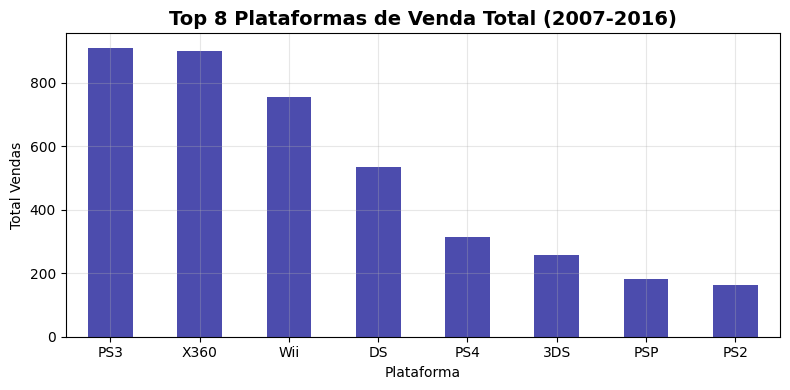

In [19]:
#Selecionando plataformas líder de vendas.
plataformas_lider_vendas = periodo_relevante.groupby(['platform','year_new'])['total_vendas'].sum().reset_index()

#Top8  plataformas por venda total no periodo relevante.
vendas_por_plataforma_periodo = periodo_relevante.groupby('platform')['total_vendas'].sum().sort_values(ascending=False)
#Top 6 de vendas por plataforma.
top_plataformas = vendas_por_plataforma_periodo.head(8)

#Grafíco ilustrativo
plt.figure(figsize=(8, 4))
top_plataformas.plot(kind='bar', color='darkblue', alpha=0.7)
plt.title('Top 8 Plataformas de Venda Total (2007-2016)',fontsize=14, fontweight='bold')
plt.xlabel('Plataforma')
plt.ylabel('Total Vendas')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

O Gráfico ilustra o top8 em vendas durante os últimos 10 anos. (período de 2007 a 2016) 

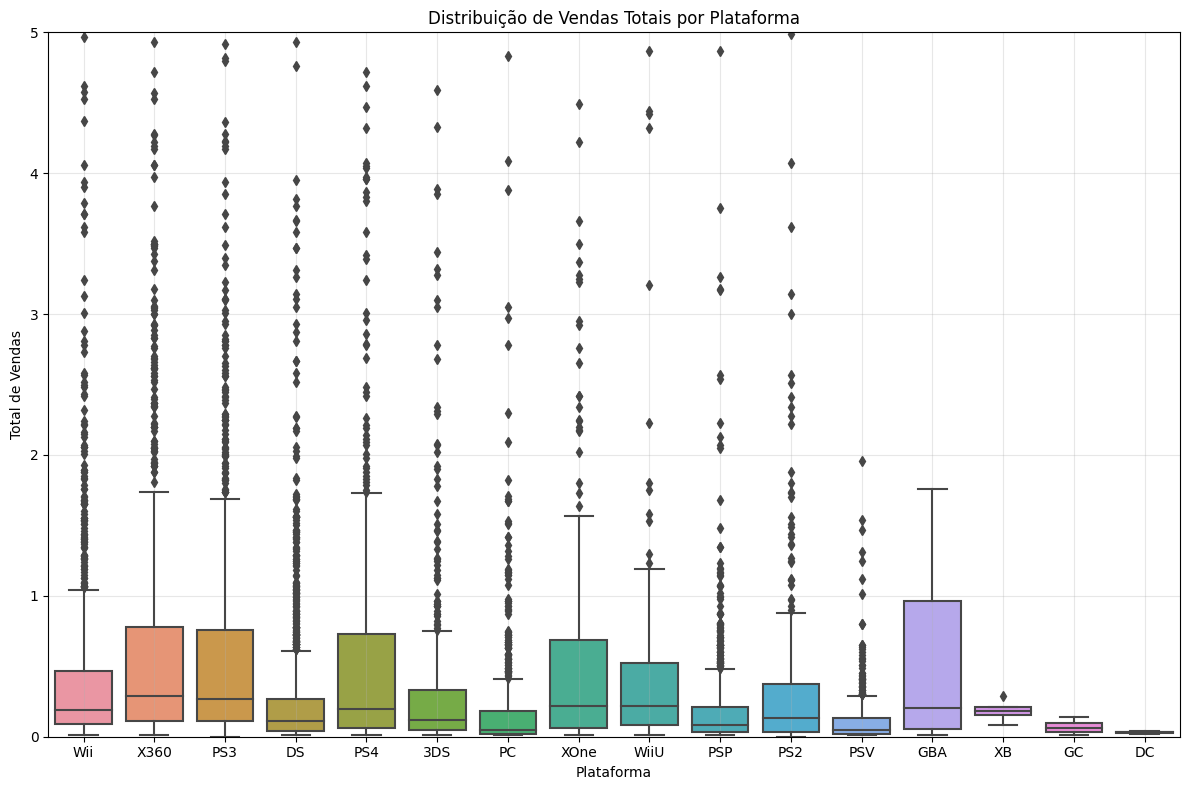

In [20]:
#Boxplot Ilustrando o gráfico do top8 vendas do período relevante (2007 - 2016)

plt.figure(figsize=(12,8))
sns.boxplot(data=periodo_relevante, x='platform', y='total_vendas')
plt.ylim(0, 5)
plt.title('Distribuição de Vendas Totais por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Total de Vendas')
plt.xticks(rotation=0)
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

O boxplot ilustra uma mediana estavel ao longos dos 10 anos de analíse (2007 á 2016), isso mostra que os jogos vendem uma quantidade similiar independente da plataforma. Já a maxíma e os outliers de algumas plataformas tiveram um disparado muito grande, o que pode ser uma resposta dos números excepcioanis em vendas. Podemos ver que o boxplot acompanha o Subplot(6)

In [21]:
#Criando uma variável com apenas as linha em que tenha PS3.
ps3_data = periodo_relevante[periodo_relevante['platform'] == 'PS3'].copy()

#Removendo os valores 'nan' das colunas critic_score e user_score.
ps3_clean = ps3_data.dropna(subset=['critic_score','user_score'])

# E usando as linhas aonde não tem valores 'tbd' em user score
ps3_clean = ps3_clean[ps3_clean['user_score']!= 'tbd']

#convertendo os valores da coluna user score para númerico.
ps3_clean['user_score'] = pd.to_numeric(ps3_clean['user_score'])

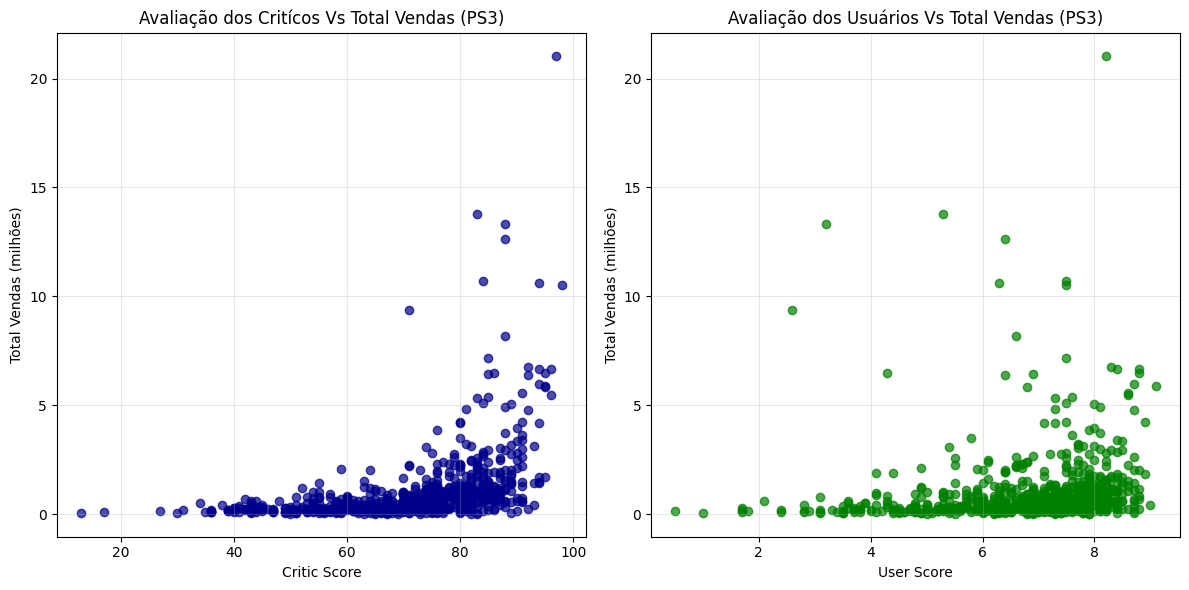

In [22]:
#Grafícos para ilustrar a variação de vendas com base em critic ou user score. 
fig, axes = plt.subplots(1, 2, figsize=(12,6))

#Grafíco 1 critic score VS vendas.
axes[0].scatter(ps3_clean['critic_score'],
                ps3_clean['total_vendas'],
                color='darkblue',
                alpha= 0.7)
axes[0].set_title('Avaliação dos Critícos Vs Total Vendas (PS3)')
axes[0].set_xlabel('Critic Score')
axes[0].set_ylabel('Total Vendas (milhões)')
axes[0].grid(True, alpha=0.3)

#Grafíco 2 user score VS vendas.
axes[1].scatter(ps3_clean['user_score'], 
                ps3_clean['total_vendas'], 
                color='green',
                alpha=0.7)
    
axes[1].set_title('Avaliação dos Usuários Vs Total Vendas (PS3)')
axes[1].set_xlabel('User Score')
axes[1].set_ylabel('Total Vendas (milhões)') 
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
                   

Os Gráficos ilutram, que as vendas dos jogos não são afetadas com base na pontuação crítica dos críticos ou dos usuários. 

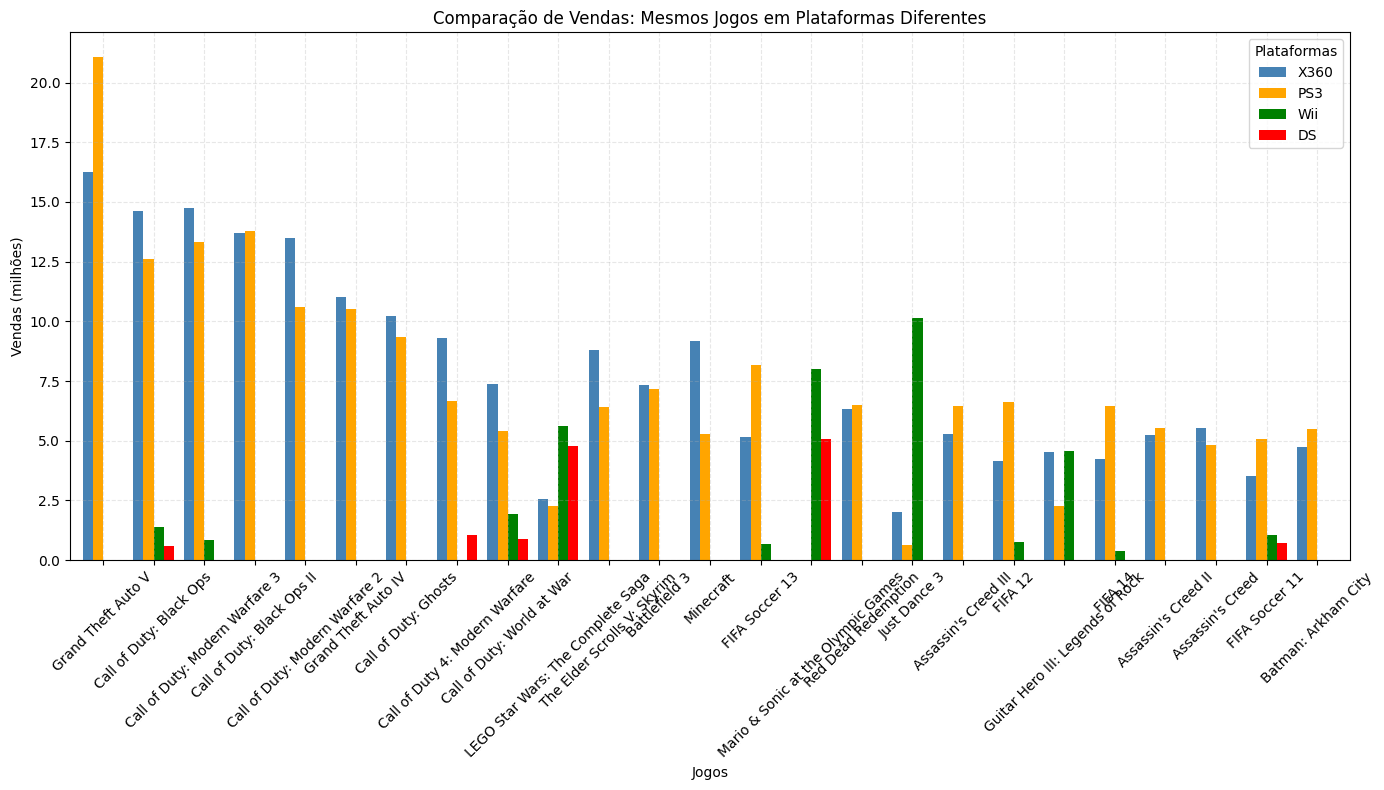

In [23]:
#Comparando as vendas dos jogos em plataformas diferentes. 
top_4_consoles = ['X360','PS3', 'Wii', 'DS']
dados_consoles = periodo_relevante[periodo_relevante['platform'].isin(top_4_consoles)]

#Selecionando os jogos multiplataformas
contagem_plataforma = dados_consoles.groupby('name')['platform'].nunique()
jogos_multi = contagem_plataforma[contagem_plataforma >= 2].index

tabela_comparacao = (
    dados_consoles[dados_consoles['name'].isin(jogos_multi)]
    .groupby(['name','platform'])['total_vendas'].sum()
    .unstack(fill_value=0).reindex(columns=top_4_consoles)
)

#Selecioando top 25 jogos multiplataformas.
top_25_jogos = tabela_comparacao.sum(axis=1).nlargest(25).index
dados_grafico = tabela_comparacao.loc[top_25_jogos]


#Grafíco ilustrando top 25 jogos multiplataformas.

ax = dados_grafico.plot(kind='bar',
                        figsize=(14,8),
                        color=['steelblue','orange','green','red'],
                        width=0.8)
plt.title('Comparação de Vendas: Mesmos Jogos em Plataformas Diferentes')
plt.xlabel('Jogos')
plt.ylabel('Vendas (milhões)')
plt.legend(title='Plataformas')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()



O Gráfico ilutra que o Ps3 é popularmente uma plataforma mais escolhida, seguindo do x360 e em algumas rara execessões outra platorma, lídera o número de vendas.

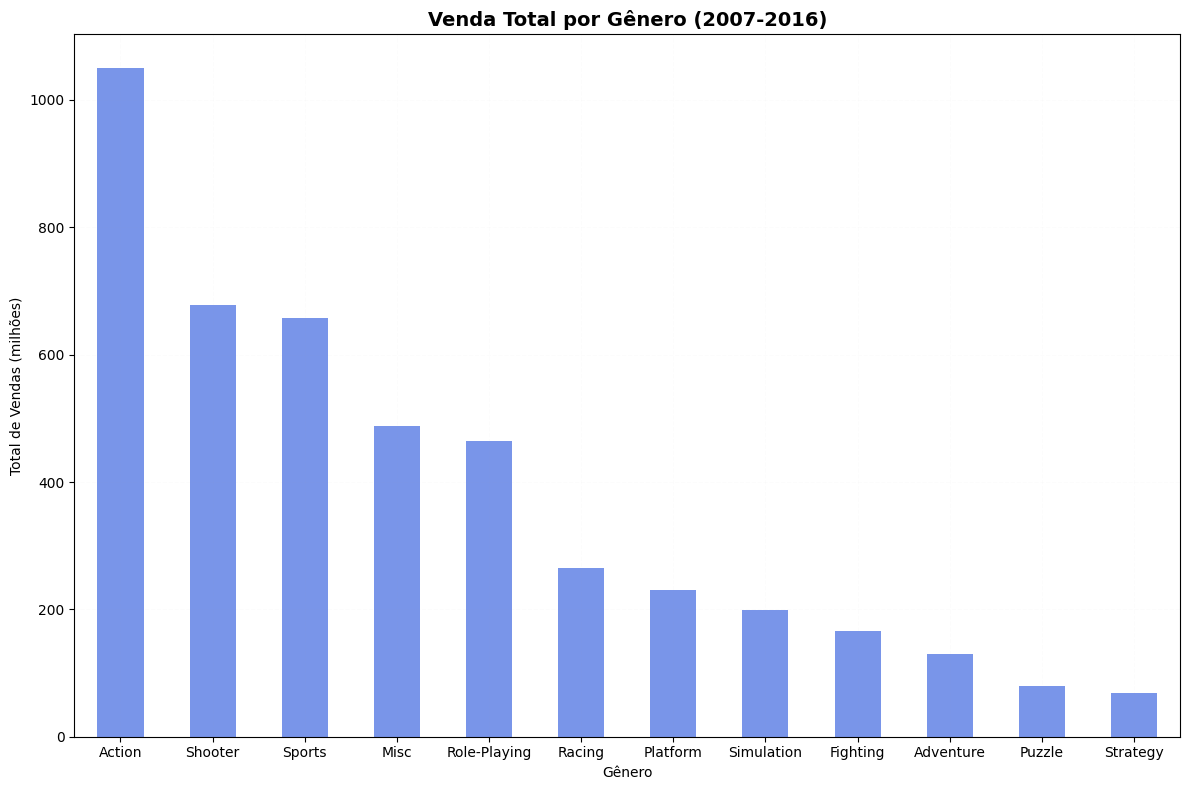

In [24]:
#Contando os jogos por gênero período de 2007 a 2016.
jogos_por_genero = periodo_relevante['genre'].value_counts()

#Vendas totais por gênero.
vendas_por_genero = periodo_relevante.groupby('genre')['total_vendas'].sum().sort_values(ascending= False)

#Selecionando o top25 em vendas nos 
top_25_genre = vendas_por_genero.head(25).index
genre_grafico = vendas_por_genero.loc[top_25_genre]

plt.figure(figsize=(12,8))
ax = genre_grafico.plot(kind='bar',
                       color='royalblue',
                       alpha=0.7)
plt.title('Venda Total por Gênero (2007-2016)', fontsize=14, fontweight='bold')
plt.xlabel('Gênero')
plt.ylabel('Total de Vendas (milhões)')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.03, linestyle='--')
plt.tight_layout()
plt.show()

O Gráfico ilutra que o gênero 'Action' se manteve superior nos últimos 10 anos, enquanto 'Shooter' e 'Sports'praticamente dividem a segundo passição de gênero mais consumidos pelos usuários nesse período. 

## Criando perfil de usuário para cada região

==ANÁLISE REGIÃO NA ==


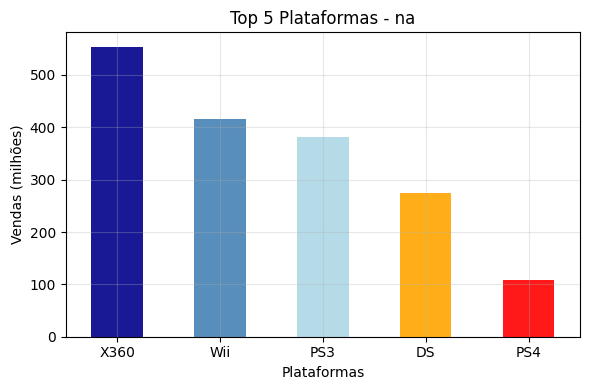


 Quotas Mercado - NA:
  X360:26.1%
  Wii:19.6%
  PS3:17.9%
  DS:12.9%
  PS4:5.1%
Total das Top 5: 81.6%
----------------------------------------
==ANÁLISE REGIÃO JP ==


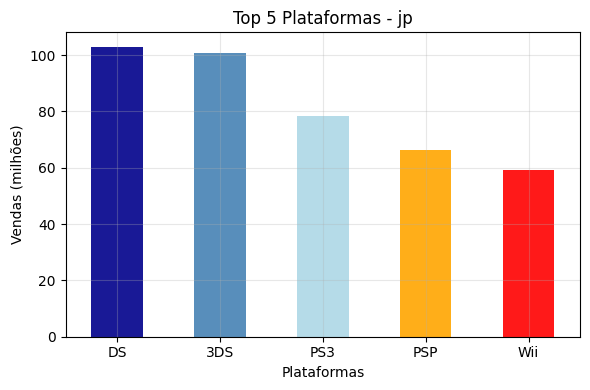


 Quotas Mercado - JP:
  DS:21.1%
  3DS:20.6%
  PS3:16.1%
  PSP:13.6%
  Wii:12.1%
Total das Top 5: 83.5%
----------------------------------------
==ANÁLISE REGIÃO EU ==


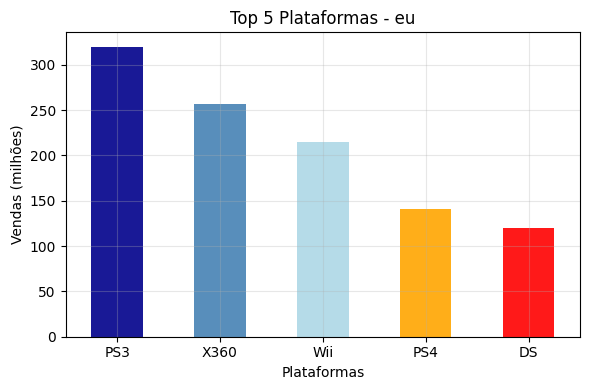


 Quotas Mercado - EU:
  PS3:23.4%
  X360:18.8%
  Wii:15.7%
  PS4:10.3%
  DS:8.8%
Total das Top 5: 76.9%
----------------------------------------
==ANÁLISE REGIÃO OTHER ==


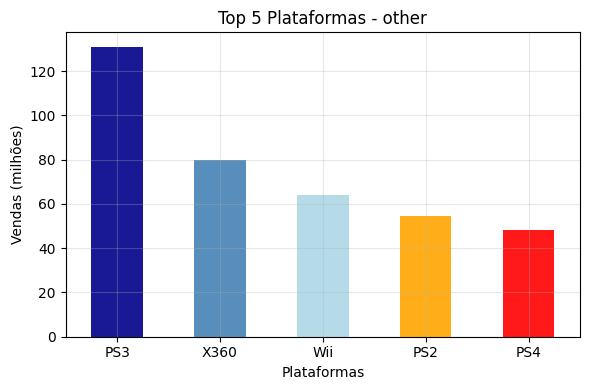


 Quotas Mercado - OTHER:
  PS3:26.2%
  X360:16.0%
  Wii:12.9%
  PS2:10.9%
  PS4:9.7%
Total das Top 5: 75.7%
----------------------------------------


platform
PS3     130.93
X360     79.82
Wii      64.19
PS2      54.46
PS4      48.35
Name: other_sales, dtype: float64

In [25]:
#Separando as 5 plataformas principais de cada região( Na, Eu, Jp e Other).
def criar_grafico_regiao(regiao):
    dados_grafico_plataforma = periodo_relevante.groupby('platform')[f'{regiao}_sales'].sum()
    top5_plataforma = dados_grafico_plataforma.sort_values(ascending=False).head(5)
    
#Calculando o valor da quota de cada região.
    total_vendas_regiao = dados_grafico_plataforma.sum()
    quotas_originais = (top5_plataforma / total_vendas_regiao) * 100

#Gráficos para ilustrar as vendas das 5 principais plataformas de cada região (Na, Eu, Jp e Other).
    top5_plataforma.plot(kind='bar', 
                         title= f'Top 5 Plataformas - {regiao}',
                         color=['darkblue', 'steelblue', 'lightblue', 'orange', 'red'],
                         alpha=0.9,
                         figsize=(6,4))
    plt.xlabel('Plataformas')
    plt.ylabel('Vendas (milhões)')
    plt.xticks(rotation=0)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show() 

#Exibindo as quotas de cada plataformas em relação as vendas por região (Na, Eu, Jp e Other).
    print(f'\n Quotas Mercado - {regiao.upper()}:')
    for platform, quotas in quotas_originais.items():
        print(f'  {platform}:{quotas:.1f}%')
    print(f'Total das Top 5: {quotas_originais.sum():.1f}%')
    print('-' * 40)
    return top5_plataforma 


print('==ANÁLISE REGIÃO NA ==')
criar_grafico_regiao('na')

print('==ANÁLISE REGIÃO JP ==')
criar_grafico_regiao('jp')

print('==ANÁLISE REGIÃO EU ==')
criar_grafico_regiao('eu')

print('==ANÁLISE REGIÃO OTHER ==')
criar_grafico_regiao('other')


Os Gráficos ilutram que o perfil dos usuários do Japão é totalmente diferente das outras regiões, enquando no japão as plataformas portáteis lidaram em vendas. Mas demais regiões, temos suas variações de preferencia, mas seguem uma linha muito parecida de estilo de plataforma. Na Europa a preferência é pelo PS3, Norte Americana a preferência é pelo X360 e em outras regiões o PS3 também lidera em vendas.

In [26]:
#Separando os 5 principais gêneros de cada região( Na, Eu, Jp e Other).
def principais_generos(regiao):
    dados_genero_regiao = periodo_relevante.groupby('genre')[f'{regiao}_sales'].sum()
    top5_genero = dados_genero_regiao.sort_values(ascending=False).head(5)

    print(f'\n === TOP 5 GÊNEROS - {regiao.upper()} ===')
    for i, (genre,vendas) in enumerate (top5_genero.items(),1):
        print(f'{i}.{genre} : {vendas:.2f} milhões') 
        
#Imprimindo 
principais_generos('na')
principais_generos('eu')
principais_generos('jp')
principais_generos('other')


 === TOP 5 GÊNEROS - NA ===
1.Action : 492.17 milhões
2.Shooter : 350.11 milhões
3.Sports : 323.86 milhões
4.Misc : 259.16 milhões
5.Role-Playing : 175.41 milhões

 === TOP 5 GÊNEROS - EU ===
1.Action : 335.67 milhões
2.Shooter : 230.16 milhões
3.Sports : 211.49 milhões
4.Misc : 127.62 milhões
5.Racing : 104.63 milhões

 === TOP 5 GÊNEROS - JP ===
1.Role-Playing : 150.55 milhões
2.Action : 96.29 milhões
3.Misc : 48.79 milhões
4.Sports : 40.28 milhões
5.Adventure : 26.91 milhões

 === TOP 5 GÊNEROS - OTHER ===
1.Action : 126.46 milhões
2.Sports : 82.44 milhões
3.Shooter : 81.07 milhões
4.Misc : 52.32 milhões
5.Role-Playing : 36.40 milhões


Preferências de gênero variam por região, com Action domina globalmente, enquanto o Japão apresenta forte inclinação para Role-Playing (RPG domina).

        na_sales  eu_sales  jp_sales  other_sales
rating                                           
E         663.99    393.08     95.06       138.48
E10+      287.61    162.75     31.91        61.97
EC          1.32      0.00      0.00         0.08
M         546.55    385.86     41.09       134.30
RP          0.00      0.03      0.00         0.01
T         371.32    217.89     74.74        94.12


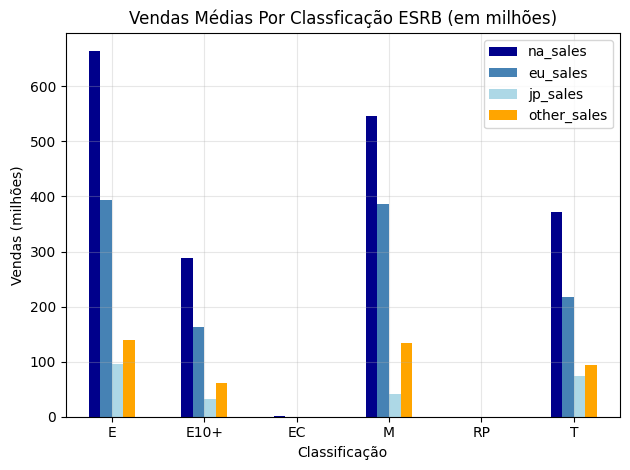

In [27]:
#Excluindo as linhas nan da coluna rating(classificação)
dados_rating = periodo_relevante.dropna(subset=['rating']).copy()

#Fazendo uma tabela com todos os dados das classificações por região.
def rating_por_regiao():
    vendas_medias_rating = dados_rating.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()
    
    print(vendas_medias_rating.round(3))
    return vendas_medias_rating

# Grafico para ilustrar
vendas_por_rating = rating_por_regiao()
vendas_por_rating.plot(kind='bar',
                       color=['darkblue', 'steelblue', 'lightblue', 'orange'])
plt.title('Vendas Médias Por Classficação ESRB (em milhões)')
plt.ylabel('Vendas (milhões)')
plt.xlabel('Classificação')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Jogos com classificação(E) tem maior alcance global, enquanto a classificação (M) dependem mais do mercado ocidental.

## Teste de Hipóteses

1 - As avaliações médias dos usuários para Xbox One e PC são iguais.
Com um nível de significância (a= 0.05).

H₀: A classificação média dos usuários da plataforma Xbox One é igual da classificação média dos usuários de PC.                         
 H₁: A classificação média dos usuários da plataforma Xbox One é diferente da classificação média dos usuários de PC

In [28]:
#Criando uma variável que filtra a classificação dos usuários de X0ne.
xbox_scores = periodo_relevante[
    (periodo_relevante['platform'] == 'XOne') & 
    (periodo_relevante['user_score'] != 'tbd') & 
    (periodo_relevante['user_score'].notna())]['user_score']

#Criando uma variável que filtra a classificação dos usuários de Pc.
pc_scores = periodo_relevante[
    (periodo_relevante['platform'] == 'PC') & 
    (periodo_relevante['user_score'] != 'tbd') & 
    (periodo_relevante['user_score'].notna())]['user_score']

#Transformando as variáveis em numéricas.
xbox_scores = pd.to_numeric(xbox_scores)
pc_scores = pd.to_numeric(pc_scores)


#Teste de hipótese
alpha = 0.05

resultado = st.ttest_ind(xbox_scores , pc_scores)
print('valor-p:', resultado.pvalue)

if(resultado.pvalue < alpha):
    print('Rejeitamos a hipótese Nula')
else:
    print("Não Podemos Rejeitar a hipótese Nula")

valor-p: 0.05554752084307562
Não Podemos Rejeitar a hipótese Nula


Por mais que o resultado do teste de hipótese tenha nós mostrado que a classificação média dos usuários da plataforma Xbox One é igual da classificação média dos usuários de PC. Embora tecnicamente não possamos rejeitar H₀ (p = 0.0555 > 0.05), o valor-p muito próximo do limite sugere uma possível diferença que poderia ser confirmada com uma amostra maior, por isso eu acredito que "A classificação média dos usuários da plataforma Xbox One é diferente da classificação média dos usuários de PC".

##### 2 - As avaliações médias de usuários para os gêneros Action (ação) e Sports (esportes) são diferentes.
Nível de significância (a= 0.05).

H₀: A classificação média dos usuários para o gênero Action é igual para o do gênero Sports.                                              
                       H₁: A classificação média dos usuários para o gênero Action é diferente para o do gênero Sports.

In [29]:
#Criando uma variável que filtra a classificação do gênero Action.
action_scores = periodo_relevante[
    (periodo_relevante['genre'] == 'Action') & 
    (periodo_relevante['user_score'] != 'tbd') & 
    (periodo_relevante['user_score'].notna())]['user_score']

#Criando uma variável que filtra a classificação do gênero Sports.
sports_scores = periodo_relevante[
    (periodo_relevante['genre'] == 'Sports') & 
    (periodo_relevante['user_score'] != 'tbd') & 
    (periodo_relevante['user_score'].notna())]['user_score']

#Transformando as variáveis em dtypes numéricos.
action_scores = pd.to_numeric(action_scores)
sports_scores = pd.to_numeric(sports_scores)


#Teste de hipótese
alpha = 0.05

resultado = st.ttest_ind(action_scores , sports_scores)
print('valor-p:', resultado.pvalue)

if(resultado.pvalue < alpha):
    print('Rejeitamos a hipótese Nula')
else:
    print("Não Podemos Rejeitar a hipótese Nula")


valor-p: 1.0894514919563483e-12
Rejeitamos a hipótese Nula


Podemos notar que a  classificação média dos usuários para o gênero Action é diferente para o do gênero Sports.

# Conclusão Final 

Ao longo do projeto para a loja online Ice, pudemos observar que, de 2007 a 2011, foram os anos com maior número de lançamento de jogos. O PS2 teve o maior número de vendas no geral, seguido de três plataformas que praticamente empatam no segundo lugar (X360, PS3 e Wii). Quais plataformas se destacaram em vendas, no geral e nos últimos 10 anos... quatro plataformas têm dominado o mercado (PS3, X360, Wii e DS). Pude observar também que a classificação dos usuários e dos críticos não influencia tanto no valor das vendas. Recomendo que a Ice priorize jogos para PS3 e X360, pois dominam o mercado atual. O líder em todos os gêneros é o Action (disparado), seguido por Shooter, Sports, Misc e Role-Playing. E, por fim, conseguimos entender a preferência e demanda de cada região. Notei que três regiões têm gostos similares: NA, EU e Other, preferem jogos de Action, Shooter, Sports e Misc, e mesclam entre PS3, X360, PS2 e PS4. Já o Japão tem preferências por portáteis e prefere jogos de Role-Playing, Action, Misc e Sports (nessa ordem de preferência ambos) e tem preferências por DS, 3DS, PS3 e PSP. Os testes de hipóteses revelaram que tanto a classificação média de usuários para plataformas como XOne e PC quanto as classificações de gênero Action e Sports rejeitam as nossas suposições iniciais sobre as preferências dos usuários. Portanto, para 2017, recomendo que a Ice foque em plataformas como PS3, X360 e PS4, priorize gêneros como Action e, para o Japão, que necessita de uma estratégia específica, foque em portáteis e RPGs. Essa abordagem regional permitirá maximizar as vendas respeitando as preferências locais.